In [ ]:
#imports
# Data handling
import pandas as pd
import geopandas as gpd

#required import for geopandas (as we are using it), that was not auto installed as a dependency
import pyarrow

# Data reading
import requests
from io import BytesIO, StringIO

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns
import leafmap.foliumap as leafmap

# numpy
import numpy as np

# Feature Engineering
from sklearn.preprocessing import StandardScaler

# Unsupervised Learning
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Model requirements
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier


# Model validation
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, precision_recall_curve, auc, precision_score, recall_score

# Exploratory Data Analysis

### Read the Clean Datasets

In [2]:
# Read the OD flows parquet file into a GeoDataFrame
url_flows = "https://raw.githubusercontent.com/iansargent/nyc-subway-ridership-ml/main/Data/Clean/origin_destination_flows_CLEAN.parquet"
r_flows = requests.get(url_flows)
od_flows = gpd.read_parquet(BytesIO(r_flows.content))

# Read the origin time series file into a DataFrame
url_ts = "https://raw.githubusercontent.com/iansargent/nyc-subway-ridership-ml/main/Data/Clean/origin_ridership_time_series_CLEAN.csv"
origin = pd.read_csv(StringIO(requests.get(url_ts, verify=False).text))

### Displaying the Clean Datasets

In [3]:
display(od_flows.head())
display(origin.head())

,origin_station_complex_name,destination_station_complex_name,origin_station_complex_id,destination_station_complex_id,sum_estimated_average_ridership,geometry,distance_meters,distance_km,log_ridership,riders_per_km,origin_point_wkt,destination_point_wkt
0,Beach 44 St (A),Grand St (L),206,123,30.2032,"LINESTRING (-73.77601 40.59294, -73.94067 40.7...",19191.098843,19.191099,3.440521,1.573813,POINT (-73.776013 40.592943),POINT (-73.94067 40.711926)
1,57 St (F),"Astoria Blvd (N,W)",224,2,595.8536,"LINESTRING (-73.97745 40.76397, -73.91784 40.7...",5079.298729,5.079299,6.391672,117.310210,POINT (-73.97745 40.763972),POINT (-73.917843 40.770258)
2,Rector St (1),Buhre Av (6),329,361,8.8919,"LINESTRING (-74.01378 40.70751, -73.83257 40.8...",21749.099473,21.749099,2.291716,0.408840,POINT (-74.013783 40.707513),POINT (-73.832569 40.84681)
3,"30 Av (N,W)","Simpson St (2,5)",3,430,222.4353,"LINESTRING (-73.92148 40.76678, -73.89306 40.8...",6797.412960,6.797413,5.409122,32.723523,POINT (-73.921479 40.766779),POINT (-73.893064 40.824073)
4,"Northern Blvd (M,R)",2 Av (F),269,232,1036.2171,"LINESTRING (-73.90601 40.75288, -73.98994 40.7...",7806.638810,7.806639,6.944297,132.735371,POINT (-73.906006 40.752885),POINT (-73.989938 40.723402)


,month,day_of_week,hour_of_day,origin_station_complex_id,origin_station_complex_name,origin_latitude,origin_longitude,origin_point,sum_estimated_average_ridership
0,1,Friday,0,1,"Astoria-Ditmars Blvd (N,W)",40.775036,-73.912034,POINT (-73.912034 40.775036),35.7473
1,1,Friday,1,1,"Astoria-Ditmars Blvd (N,W)",40.775036,-73.912034,POINT (-73.912034 40.775036),11.4975
2,1,Friday,2,1,"Astoria-Ditmars Blvd (N,W)",40.775036,-73.912034,POINT (-73.912034 40.775036),10.9980
3,1,Friday,3,1,"Astoria-Ditmars Blvd (N,W)",40.775036,-73.912034,POINT (-73.912034 40.775036),14.7534
4,1,Friday,4,1,"Astoria-Ditmars Blvd (N,W)",40.775036,-73.912034,POINT (-73.912034 40.775036),52.0023


## Descriptive Statistics

In [4]:
origin[origin['day_of_week'] == 'Friday']['sum_estimated_average_ridership'].sum()

np.float64(42555436.7229)

## Distributions

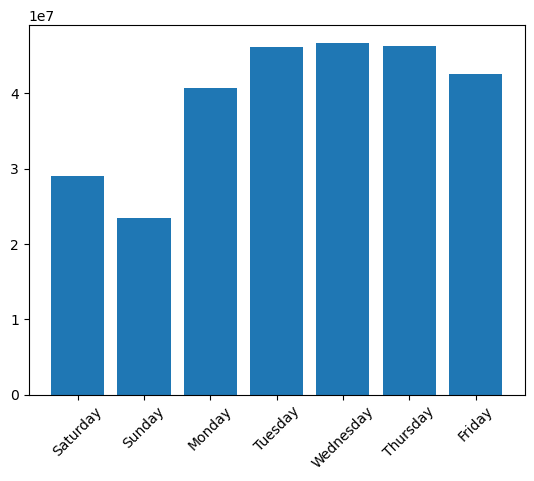

Day of the week: total ridership
Saturday: 29009734.824400004
Sunday: 23397423.0419
Monday: 40750677.3636
Tuesday: 46106946.1171
Wednesday: 46749949.310100004
Thursday: 46325195.726799995
Friday: 42555436.7229


In [5]:
# origin day of week
day_of_week = ['Saturday', 'Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
total_ridership_per_day_of_week = [origin[origin['day_of_week'] == i]['sum_estimated_average_ridership'].sum() for i in day_of_week]
plt.bar(day_of_week, total_ridership_per_day_of_week)
plt.tick_params(axis='x', labelrotation=45)
# plt.ticklabel_format(style='plain') #for some reason this is only causing an error for this graph
plt.show()
print('Day of the week: total ridership')
for i in range(7):
    print(f'{day_of_week[i]}: {total_ridership_per_day_of_week[i]}')

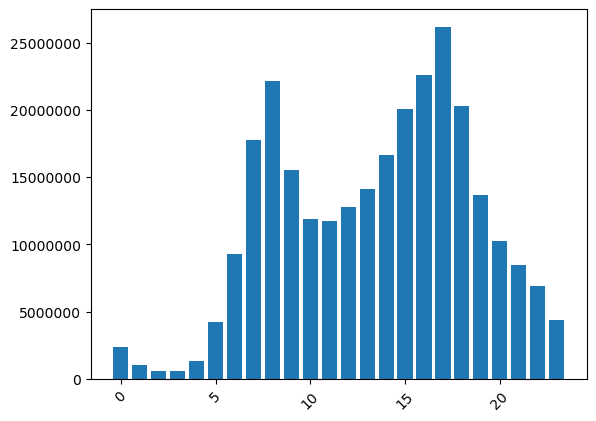

hour of the day: total ridership
0: 2355952.4046
1: 1016291.5595
2: 609685.6535
3: 587057.7875999999
4: 1326038.5767
5: 4238283.6273
6: 9272181.559999999
7: 17772294.2271
8: 22146316.1456
9: 15563042.169400001
10: 11917519.1109
11: 11710357.1202
12: 12744275.600900002
13: 14148107.2139
14: 16629629.3381
15: 20079622.951
16: 22617136.205799997
17: 26183460.9067
18: 20315118.98
19: 13689476.8277
20: 10242757.240699999
21: 8457048.3487
22: 6893768.514900001
23: 4379941.036


In [6]:
# origin hour of day
hour_of_day = origin['hour_of_day'].unique()
total_ridership_per_hour_of_day = [origin[origin['hour_of_day'] == i]['sum_estimated_average_ridership'].sum() for i in hour_of_day]
plt.bar(hour_of_day, total_ridership_per_hour_of_day)
plt.tick_params(axis='x', labelrotation=45)
plt.ticklabel_format(style='plain')
plt.show()
print('hour of the day: total ridership')
for i in range(len(hour_of_day)):
    print(f'{hour_of_day[i]}: {total_ridership_per_hour_of_day[i]}')

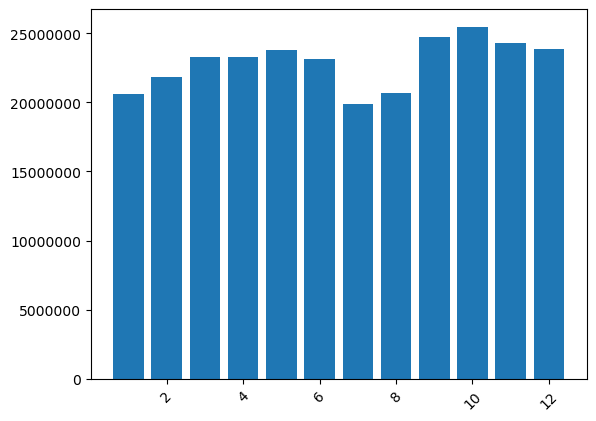

month of the year: total ridership
1: 20640117.3487
2: 21858037.6738
3: 23312621.7179
4: 23260391.0992
5: 23755413.8423
6: 23114608.935900003
7: 19875121.7932
8: 20686265.5928
9: 24742325.3384
10: 25464468.3014
11: 24320913.061899997
12: 23865078.4013


In [7]:
# origin month of year
month = origin['month'].unique()
total_ridership_per_month = [origin[origin['month'] == i]['sum_estimated_average_ridership'].sum() for i in month]
plt.bar(month, total_ridership_per_month)
plt.tick_params(axis='x', labelrotation=45)
plt.ticklabel_format(style='plain')
plt.show()
print('month of the year: total ridership')
for i in range(len(month)):
    print(f'{month[i]}: {total_ridership_per_month[i]}')

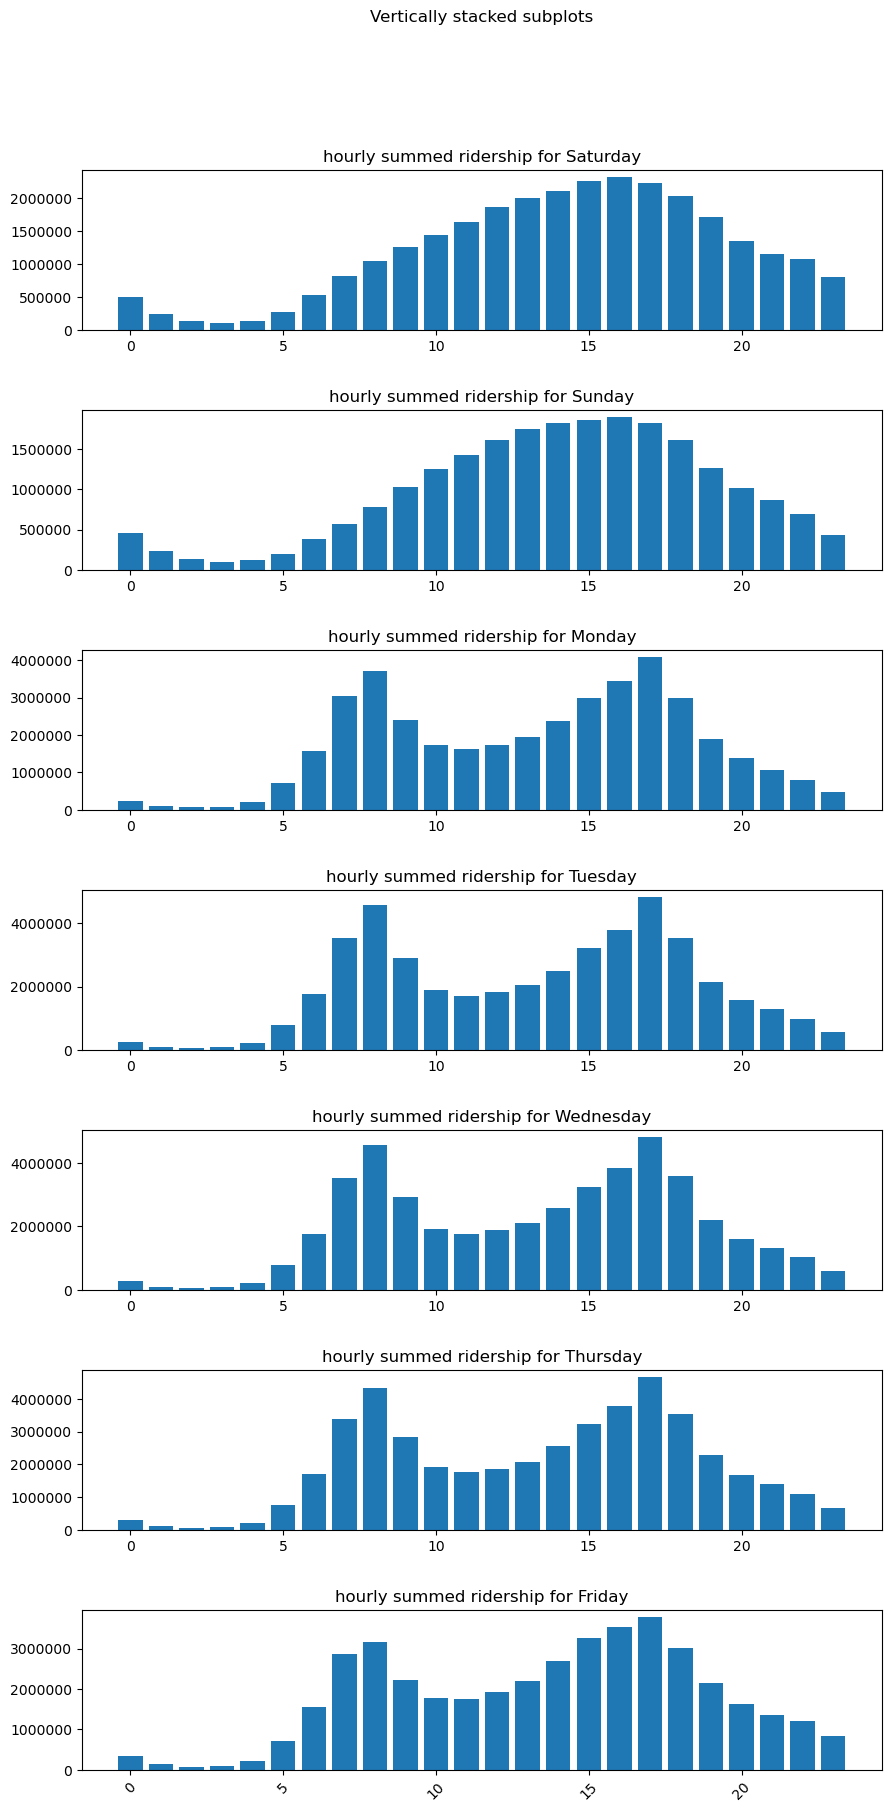

In [8]:
#origin hour of the day by day of the week
day_of_week = ['Saturday', 'Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']



fig, axs = plt.subplots(7, figsize = (10,20))
fig.suptitle('Vertically stacked subplots')
fig.subplots_adjust(wspace=0.5, hspace=0.5, top=0.9, bottom=0.1, left=0.1, right=0.9)


for i in range(7):
    daily_dataset = origin[origin['day_of_week'] == day_of_week[i]]


    hour_of_day = daily_dataset['hour_of_day'].unique()
    total_ridership_per_hour_of_day = [daily_dataset[daily_dataset['hour_of_day'] == j]['sum_estimated_average_ridership'].sum() for j in hour_of_day]
    axs[i].bar(hour_of_day, total_ridership_per_hour_of_day)
    axs[i].set_title(f'hourly summed ridership for {day_of_week[i]}')
    axs[i].ticklabel_format(style='plain')


plt.tick_params(axis='x', labelrotation=45)

plt.show()


In [9]:
origin.head()

,month,day_of_week,hour_of_day,origin_station_complex_id,origin_station_complex_name,origin_latitude,origin_longitude,origin_point,sum_estimated_average_ridership
0,1,Friday,0,1,"Astoria-Ditmars Blvd (N,W)",40.775036,-73.912034,POINT (-73.912034 40.775036),35.7473
1,1,Friday,1,1,"Astoria-Ditmars Blvd (N,W)",40.775036,-73.912034,POINT (-73.912034 40.775036),11.4975
2,1,Friday,2,1,"Astoria-Ditmars Blvd (N,W)",40.775036,-73.912034,POINT (-73.912034 40.775036),10.9980
3,1,Friday,3,1,"Astoria-Ditmars Blvd (N,W)",40.775036,-73.912034,POINT (-73.912034 40.775036),14.7534
4,1,Friday,4,1,"Astoria-Ditmars Blvd (N,W)",40.775036,-73.912034,POINT (-73.912034 40.775036),52.0023


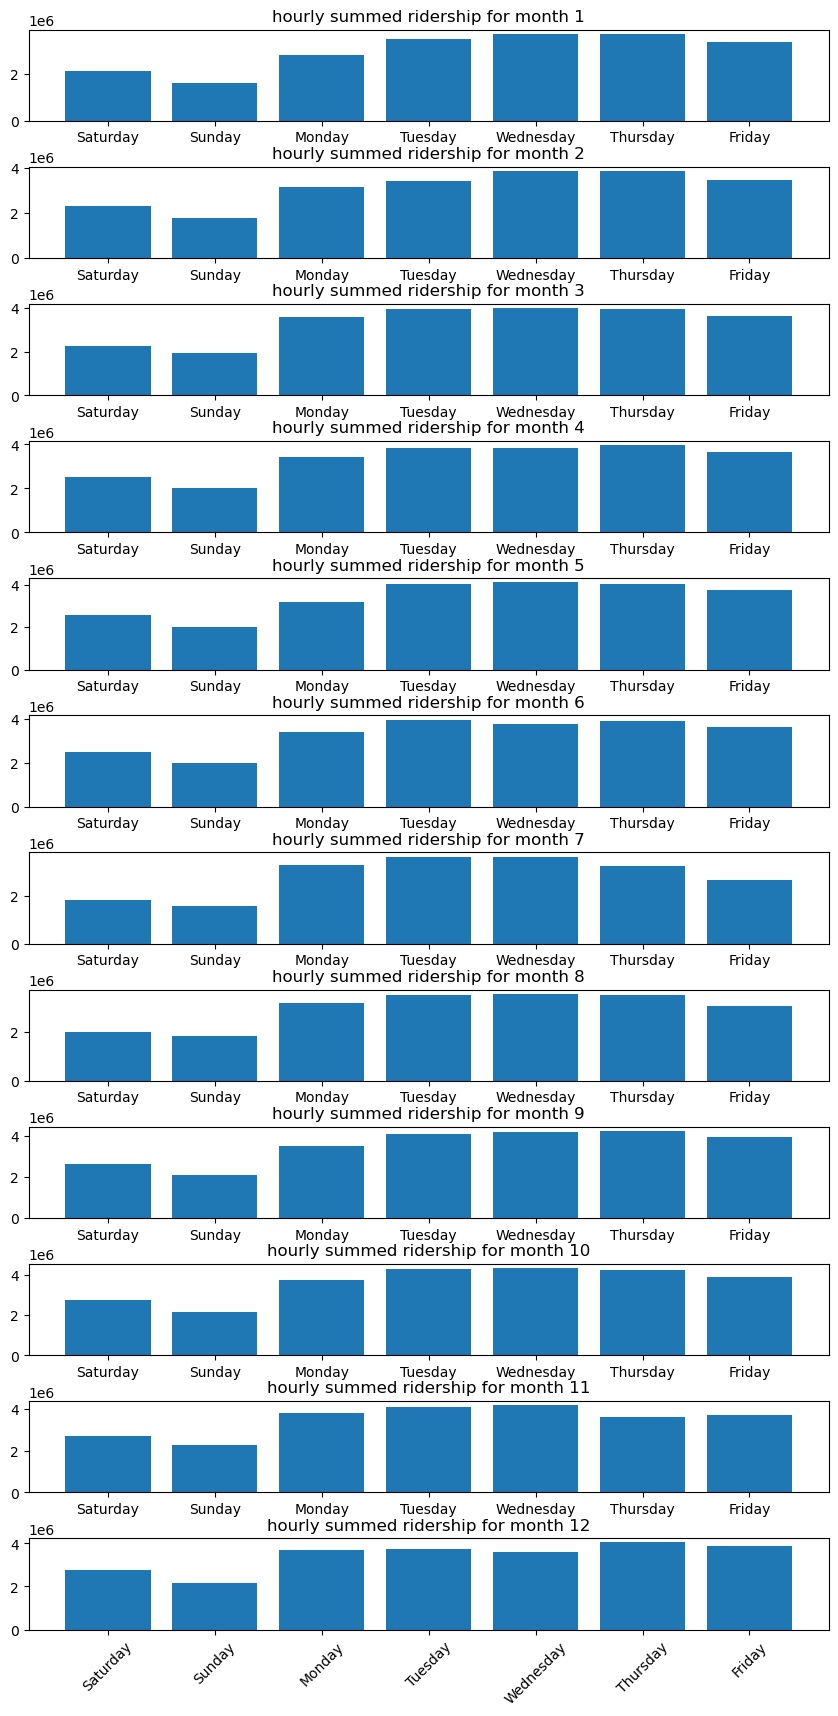

In [10]:
#origin day of the week by the month
day_of_week = ['Saturday', 'Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']



fig, axs = plt.subplots(12, figsize = (10,20))
# fig.suptitle('Vertically stacked subplots')
fig.subplots_adjust(wspace=0.5, hspace=0.5, top=0.9, bottom=0.1, left=0.1, right=0.9)


for i in range(12):
    daily_dataset = origin[origin['month'] == i+1]


    total_ridership_per_day_of_week = [daily_dataset[daily_dataset['day_of_week'] == j]['sum_estimated_average_ridership'].sum() for j in day_of_week]
    axs[i].bar(day_of_week, total_ridership_per_day_of_week)
    axs[i].set_title(f'hourly summed ridership for month {i+1}')


plt.tick_params(axis='x', labelrotation=45)

plt.show()

In [11]:
# Create a column 'Season' based on Month
origin['season'] = np.select(
    [
        (origin['month'] >= 3) & (origin['month'] <= 5),          # Condition 1
        (origin['month'] >= 6) & (origin['month'] <= 8),  # Condition 2
        (origin['month'] >= 9) & (origin['month'] <= 11),
        (origin['month'] == 12) | (origin['month'] <= 2)
    ],
    [
        'spring',  # Value if Condition 1 is True
        'summer',    # Value if Condition 2 is True
        'fall',
        'winter'
    ],
    default='Unknown'
)

origin.head()

,month,day_of_week,hour_of_day,origin_station_complex_id,origin_station_complex_name,origin_latitude,origin_longitude,origin_point,sum_estimated_average_ridership,season
0,1,Friday,0,1,"Astoria-Ditmars Blvd (N,W)",40.775036,-73.912034,POINT (-73.912034 40.775036),35.7473,winter
1,1,Friday,1,1,"Astoria-Ditmars Blvd (N,W)",40.775036,-73.912034,POINT (-73.912034 40.775036),11.4975,winter
2,1,Friday,2,1,"Astoria-Ditmars Blvd (N,W)",40.775036,-73.912034,POINT (-73.912034 40.775036),10.9980,winter
3,1,Friday,3,1,"Astoria-Ditmars Blvd (N,W)",40.775036,-73.912034,POINT (-73.912034 40.775036),14.7534,winter
4,1,Friday,4,1,"Astoria-Ditmars Blvd (N,W)",40.775036,-73.912034,POINT (-73.912034 40.775036),52.0023,winter


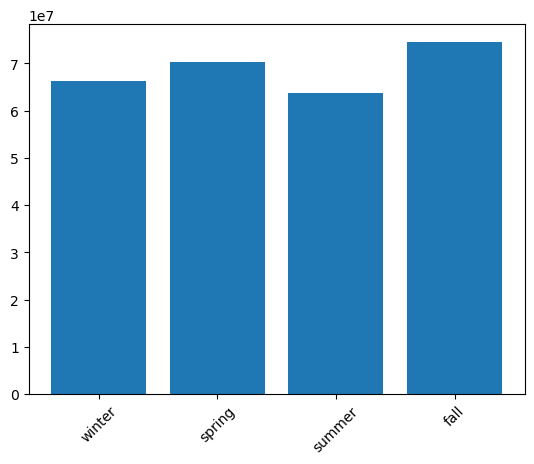

season of the year: total ridership
winter: 66363233.42380001
spring: 70328426.6594
summer: 63675996.321899995
fall: 74527706.7017


In [12]:
# origin season
season = ['winter', 'spring', 'summer', 'fall']

season = origin['season'].unique()
total_ridership_per_season = [origin[origin['season'] == i]['sum_estimated_average_ridership'].sum() for i in season]
plt.bar(season, total_ridership_per_season)
plt.tick_params(axis='x', labelrotation=45)
plt.show()
print('season of the year: total ridership')
for i in range(len(season)):
    print(f'{season[i]}: {total_ridership_per_season[i]}')

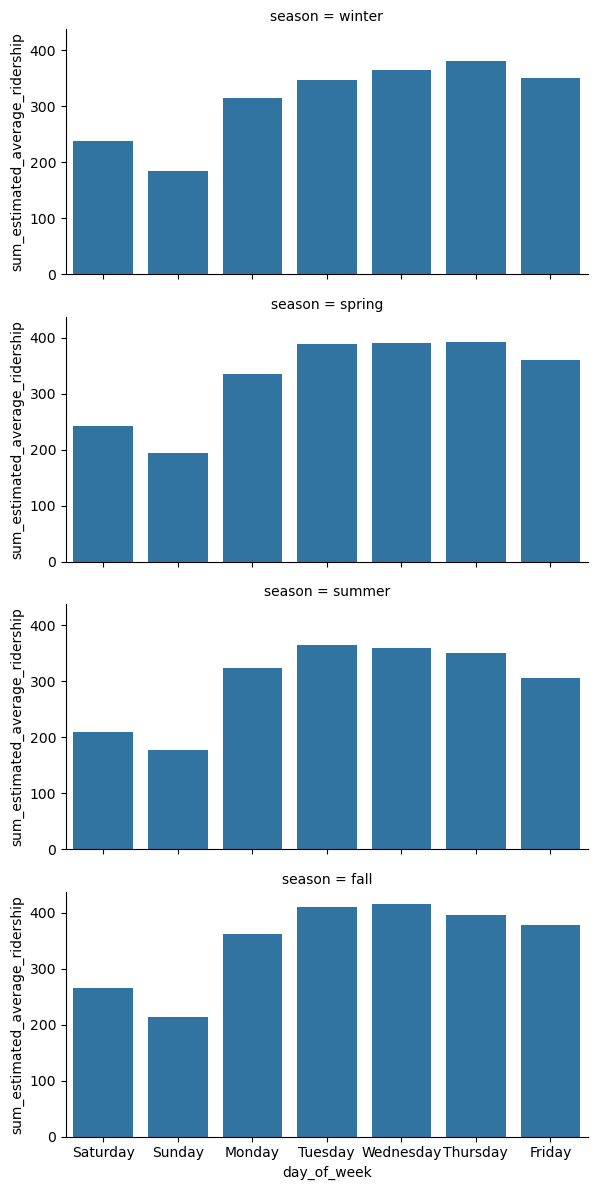

In [13]:
#origin day of the week by the season
season = ['winter', 'spring', 'summer', 'fall']
day_of_week = ['Saturday', 'Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']


# Create a faceted bar chart
g = sns.catplot(
    data=origin,
    x='day_of_week',       # X-axis variable
    y='sum_estimated_average_ridership',          # Y-axis variable
    row='season',        # Facet by 'group' (like facet_wrap in R)
    row_order= season,  # Reorder facets
    order= day_of_week,        # Reorder x-axis
    kind='bar',         # Bar chart
    errorbar=None,
    height=3,           # Height of each facet
    aspect=2            # Aspect ratio
)

# Improve layout
#g.set_axis_labels("season", "sum_estimated_average_ridership")
#plt.tight_layout()

plt.show()

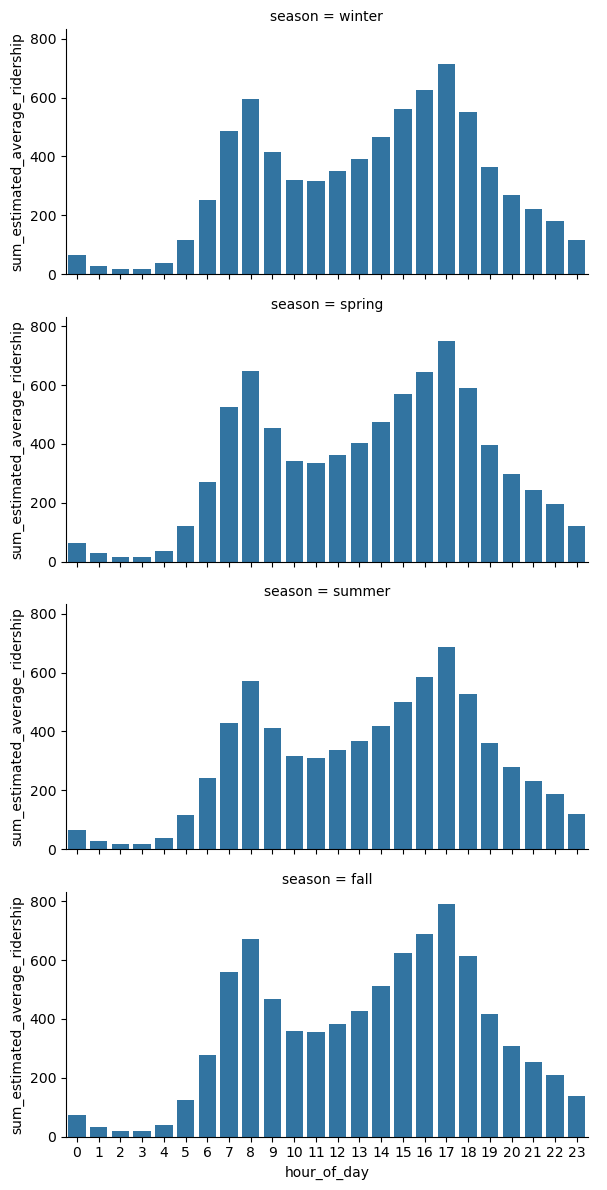

In [14]:
#origin hourly ridership by the season
season = ['winter', 'spring', 'summer', 'fall']


# Create a faceted bar chart
g = sns.catplot(
    data=origin,
    x='hour_of_day',       # X-axis variable
    y='sum_estimated_average_ridership',          # Y-axis variable
    row='season',        # Facet by 'group' (like facet_wrap in R)
    row_order= season,  # Reorder facets
    kind='bar',         # Bar chart
    errorbar=None,
    height=3,           # Height of each facet
    aspect=2            # Aspect ratio
)

plt.show()

In [15]:
# Bar graph of distribution of ridership for all destinations from a given origin point, or vice versa
display(od_flows.head())

,origin_station_complex_name,destination_station_complex_name,origin_station_complex_id,destination_station_complex_id,sum_estimated_average_ridership,geometry,distance_meters,distance_km,log_ridership,riders_per_km,origin_point_wkt,destination_point_wkt
0,Beach 44 St (A),Grand St (L),206,123,30.2032,"LINESTRING (-73.77601 40.59294, -73.94067 40.7...",19191.098843,19.191099,3.440521,1.573813,POINT (-73.776013 40.592943),POINT (-73.94067 40.711926)
1,57 St (F),"Astoria Blvd (N,W)",224,2,595.8536,"LINESTRING (-73.97745 40.76397, -73.91784 40.7...",5079.298729,5.079299,6.391672,117.310210,POINT (-73.97745 40.763972),POINT (-73.917843 40.770258)
2,Rector St (1),Buhre Av (6),329,361,8.8919,"LINESTRING (-74.01378 40.70751, -73.83257 40.8...",21749.099473,21.749099,2.291716,0.408840,POINT (-74.013783 40.707513),POINT (-73.832569 40.84681)
3,"30 Av (N,W)","Simpson St (2,5)",3,430,222.4353,"LINESTRING (-73.92148 40.76678, -73.89306 40.8...",6797.412960,6.797413,5.409122,32.723523,POINT (-73.921479 40.766779),POINT (-73.893064 40.824073)
4,"Northern Blvd (M,R)",2 Av (F),269,232,1036.2171,"LINESTRING (-73.90601 40.75288, -73.98994 40.7...",7806.638810,7.806639,6.944297,132.735371,POINT (-73.906006 40.752885),POINT (-73.989938 40.723402)


# Origin Station Clustering

### Feature Engineering

#### Recode Day of Week Variable

In [54]:
hour_pivot  = origin.groupby(['origin_station_complex_name', 'hour_of_day'])['sum_estimated_average_ridership'].mean().unstack()
dow_pivot   = origin.groupby(['origin_station_complex_name', 'day_of_week'])['sum_estimated_average_ridership'].mean().unstack()
month_pivot = origin.groupby(['origin_station_complex_name', 'month'])['sum_estimated_average_ridership'].mean().unstack()

station_df  = pd.concat([hour_pivot, dow_pivot, month_pivot], axis=1)
station_df.columns = (
    [f"hour_{h:02d}" for h in range(24)] +
    [f"dow_{d}"      for d in range(7)]  +
    [f"month_{m:02d}" for m in range(1, 13)]
)

station_df

,hour_00,hour_01,hour_02,hour_03,hour_04,hour_05,hour_06,hour_07,hour_08,hour_09,...,month_03,month_04,month_05,month_06,month_07,month_08,month_09,month_10,month_11,month_12
origin_station_complex_name,,,,,,,,,,,,,,,,,,,,,
1 Av (L),226.769186,111.846351,64.253615,37.154957,27.351614,56.752556,223.877729,660.538508,1316.810330,944.104951,...,665.972376,671.063568,730.480807,673.380765,597.192020,644.404501,778.906904,867.580778,812.394774,740.556502
103 St (1),39.052715,11.558332,7.898737,7.096830,15.929852,48.406736,140.075049,450.808646,791.565054,588.484492,...,337.966900,303.469446,325.724330,309.890245,268.075235,277.195624,352.313677,344.714583,356.728211,301.318145
103 St (6),23.195361,12.158142,10.520164,11.328379,26.021038,81.647530,209.854410,487.191511,596.532720,379.434637,...,286.478766,282.228977,283.081675,268.807772,221.919565,227.197331,301.526476,323.397310,320.324373,312.040435
"103 St (C,B)",11.926493,4.350546,3.039625,3.584062,7.623933,23.338936,77.582369,214.009362,331.234680,232.117374,...,121.711599,119.212226,128.946353,133.847206,112.920046,110.337716,131.308093,136.845620,106.965482,123.484630
103 St-Corona Plaza (7),57.216176,42.740326,41.908095,75.053321,307.260507,1080.197112,1692.803336,2293.198961,1833.409098,1209.640380,...,782.701078,778.439690,729.312895,704.555870,614.767946,631.801698,726.182159,737.533891,723.790127,711.957485
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"Woodhaven Blvd (J,Z)",6.535745,4.316488,3.459004,8.184611,23.295590,65.091530,114.564973,190.797993,162.306299,101.460360,...,36.640898,38.487725,37.743230,41.151410,34.656174,57.713134,117.610237,123.174746,114.212937,105.350176
"Woodhaven Blvd (M,R)",30.367924,12.813948,10.499926,25.201973,86.447762,421.899489,812.212621,1291.631315,1265.310463,793.937374,...,472.990973,472.443639,483.760824,482.565351,428.729343,447.700970,504.750477,530.385974,520.956189,543.607739
Woodlawn (4),27.663074,15.238167,8.208282,15.000014,48.369676,225.352102,373.027965,492.299948,354.859740,206.939614,...,150.239056,154.234124,157.731485,161.239310,136.656738,138.511624,175.010657,172.372645,158.653437,138.542297


#### Scale the Data (Standardize)

In [ ]:
X = np.array(
    station_df.reset_index()
    .drop(columns="origin_station_complex_name")
)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

array([[ 1.02683041,  1.28736655,  1.42670097, ...,  0.99084459,
         0.95734692,  0.80344243],
       [-0.1737403 , -0.26304793, -0.28005958, ..., -0.02486379,
         0.03103391, -0.0668228 ],
       [-0.27515855, -0.25377511, -0.20066718, ..., -0.06627425,
        -0.04297053, -0.04557867],
       ...,
       [-0.24658458, -0.2061591 , -0.27068471, ..., -0.35965144,
        -0.37162728, -0.38933143],
       [-0.01547554, -0.06942428, -0.19555365, ...,  0.17142039,
         0.13374608,  0.17223724],
       [-0.41199229, -0.42038094, -0.4698862 , ..., -0.57920533,
        -0.58235697, -0.55221897]])

### Principal Component Analysis (PCA)

In [61]:
# Define PCA object
pca = PCA(n_components = 2)
# Fit to the previously scaled X feature array
X_pca = pca.fit_transform(X_scaled)

# Create dataframe with first two principal components (for plotting)
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])

# Concatenate the station labels to each observation
pca_df["station"] = station_df.reset_index()["origin_station_complex_name"]

# Sort by PC1 descending to find extreme outlier stations
pca_df.sort_values(by="PC1", ascending=False).head(10)


,PC1,PC2,station
399,67.613375,6.138826,"Times Sq-42 St (N,Q,R,W,S,1,2,3,7)/42 St (A,C,E)"
282,43.456091,-2.216307,"Grand Central-42 St (S,4,5,6,7)"
85,33.396352,-3.860037,"34 St-Herald Sq (B,D,F,M,N,Q,R,W)"
26,30.179508,-5.761502,"14 St-Union Sq (L,N,Q,R,W,4,5,6)"
88,23.402935,1.157492,"34 St-Penn Station (A,C,E)"
276,22.942293,-2.266203,"Fulton St (A,C,J,Z,2,3,4,5)"
87,20.757955,2.808288,"34 St-Penn Station (1,2,3)"
111,20.689347,-4.025151,"59 St-Columbus Circle (A,B,C,D,1)"
126,20.097537,10.773083,"74-Broadway (7)/Jackson Hts-Roosevelt Av (E,F,..."
263,18.320336,9.126264,Flushing-Main St (7)


<Axes: xlabel='PC1', ylabel='PC2'>

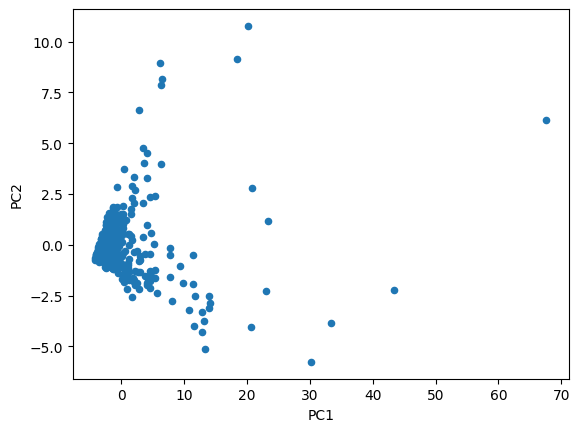

In [62]:
# Scatterplot of PC1 and PC2 (Not really any patterns)
pca_df.plot(x='PC1', y = "PC2", kind='scatter')

# Decision trees

### Train-Test Split

In [5]:
#split into X and Y datasets
num_cols = origin.shape[1]
X = origin.iloc[:,0:num_cols-2]
X = X.drop('origin_station_complex_id', axis=1) #drop complex_id b/c it is the same as complex_name in terms of analysis
X = pd.get_dummies(X, drop_first=True) #one_hot encoding here
Y = origin.iloc[:,num_cols-1:num_cols]
Y = np.ravel(Y)

In [6]:
from sklearn.preprocessing import OneHotEncoder

#split into X and Y datasets
num_cols = origin.shape[1]
X = origin.iloc[:,0:num_cols-2]
X = X.drop('origin_station_complex_id', axis=1) #drop complex_id b/c it is the same as complex_name in terms of analysis
#one hot encoding
categorical_columns = X.select_dtypes(include=['object']).columns.tolist()
encoder = OneHotEncoder(sparse_output=False, drop = 'first')
one_hot_encoded = encoder.fit_transform(X[categorical_columns])
one_hot_df = pd.DataFrame(one_hot_encoded, columns=encoder.get_feature_names_out(categorical_columns))
df_encoded = pd.concat([X, one_hot_df], axis=1)
df_encoded = df_encoded.drop(categorical_columns, axis=1)
X = df_encoded

Y = origin.iloc[:,num_cols-1:num_cols]
Y = np.ravel(Y)


display(X)

,month,hour_of_day,origin_latitude,origin_longitude,day_of_week_Monday,day_of_week_Saturday,day_of_week_Sunday,day_of_week_Thursday,day_of_week_Tuesday,day_of_week_Wednesday,...,"origin_station_complex_name_West Farms Sq-E Tremont Av (2,5)",origin_station_complex_name_Westchester Sq-E Tremont Av (6),origin_station_complex_name_Whitlock Av (6),origin_station_complex_name_Wilson Av (L),"origin_station_complex_name_Winthrop St (2,5)","origin_station_complex_name_Woodhaven Blvd (J,Z)","origin_station_complex_name_Woodhaven Blvd (M,R)",origin_station_complex_name_Woodlawn (4),origin_station_complex_name_York St (F),origin_station_complex_name_Zerega Av (6)
0,1,0,40.775036,-73.912034,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,1,40.775036,-73.912034,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1,2,40.775036,-73.912034,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1,3,40.775036,-73.912034,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1,4,40.775036,-73.912034,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
852928,12,19,40.692259,-73.986642,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
852929,12,20,40.692259,-73.986642,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
852930,12,21,40.692259,-73.986642,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
852931,12,22,40.692259,-73.986642,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
#train test split happening
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.25, random_state=4)

### Decision Tree Model

In [ ]:
#full model takes a while

In [8]:
ridership_tree = (
    DecisionTreeRegressor(random_state = 3870)
    .fit(X = X_train, y = y_train)
)

In [9]:
R2_train = ridership_tree.score(X_train, y_train)
R2_test = ridership_tree.score(X_test, y_test)

print(f'R-squared for the training set is:{np.sqrt(R2_train): .2f} and the R-squared of the test set is {np.sqrt(R2_test): .2f}')

R-squared for the training set is: 1.00 and the R-squared of the test set is  0.99


### Pruning the Tree

some notes
- need to add constraints, model was taking, way, way to long to run if I do not
- i am sure my previous code chunk had mistakes, but i left it to run for 10 hours and it did not finish, sooooo, I decided to move on to another less computationally expensive method that should work about as well
- the one below takes a lot less time
  - still takes like 20 minutes though

In [17]:
from sklearn.model_selection import GridSearchCV


param_grid = {'max_depth':range(1, 200, 3)}
cross_val_tree = DecisionTreeRegressor()
search = GridSearchCV(cross_val_tree, param_grid, cv=5, scoring = 'r2')
grid_search = search.fit(X_train, y_train)


Text(0, 0.5, 'Val Accuracy')

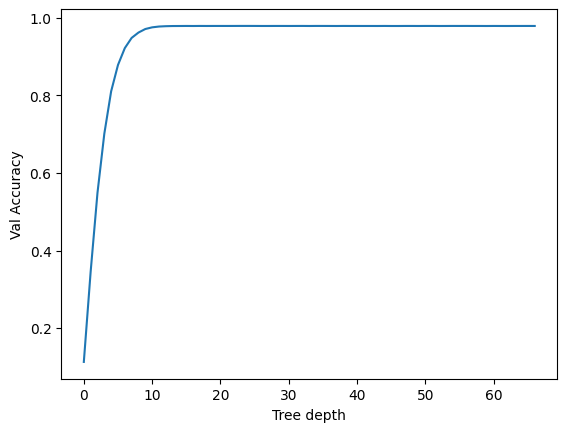

In [18]:
plt.plot(search.cv_results_['mean_test_score'])
plt.xlabel('Tree depth')
plt.ylabel('Val Accuracy')

In [24]:
depth = grid_search.best_params_['max_depth']
print(depth)
ridership_tree_pruned = DecisionTreeRegressor(max_depth=depth).fit(X_train, y_train)
R2_train = ridership_tree_pruned.score(X_train, y_train)
R2_test = ridership_tree_pruned.score(X_test, y_test)

print(f'R-squared for the training set is:{np.sqrt(R2_train): .2f} and the R-squared of the test set is {np.sqrt(R2_test): .2f}')

73
R-squared for the training set is: 1.00 and the R-squared of the test set is  0.99


In [25]:
# code from: https://scikit-learn.org/1.4/model_persistence.html#:~:text=9.-,Model%20persistence
#for more, consider this website: https://wandb.ai/a-sh0ts/publications/reports/How-to-Save-a-Classifier-to-Disk-in-Scikit-learn--Vmlldzo0NDc1ODI0
#saving the model
import pickle

with open('pruned_tree.pkl', 'wb') as f:
    pickle.dump(ridership_tree_pruned, f)

#to read the file
# with open('pruned_tree.pkl', 'rb') as f:
#    ridership_tree_pruned = pickle.load(f)
#

### Feature importance


In [26]:
feat_import_pruned = ridership_tree_pruned.feature_importances_
feat_import_full = ridership_tree.feature_importances_

feat_import_df = pd.DataFrame({
        'feature': X_train.columns,
        'full': feat_import_full,
        'pruned': feat_import_pruned
    }).sort_values(by = 'pruned').reset_index().drop(columns = 'index', axis = 1)

In [27]:
feat_import_df

,feature,full,pruned
0,origin_station_complex_name_Beach 36 St (A),9.959052e-09,6.799157e-09
1,origin_station_complex_name_Beach 44 St (A),8.482758e-09,1.023535e-08
2,origin_station_complex_name_Neptune Av (F),2.589623e-08,1.719308e-08
3,origin_station_complex_name_Avenue N (F),2.734641e-08,3.264335e-08
4,origin_station_complex_name_Avenue P (F),4.191795e-08,3.881893e-08
...,...,...,...
428,origin_station_complex_name_Grand Central-42 S...,6.423496e-02,6.423498e-02
429,origin_longitude,8.279595e-02,8.296591e-02
430,origin_latitude,1.175492e-01,9.667989e-02
431,"origin_station_complex_name_Times Sq-42 St (N,...",1.127163e-01,1.127163e-01


In [29]:
feat_import_df = feat_import_df[feat_import_df['full'] >= .01]
feat_import_df = feat_import_df[feat_import_df['pruned'] >= .01]
feat_import_df

,feature,full,pruned
418,origin_station_complex_name_34 St-Penn Station...,0.010007,0.010007
419,origin_station_complex_name_59 St-Columbus Cir...,0.010748,0.010748
420,origin_station_complex_name_Flushing-Main St (7),0.013404,0.013404
421,origin_station_complex_name_74-Broadway (7)/Ja...,0.013571,0.013571
422,month,0.015041,0.015042
424,"origin_station_complex_name_Fulton St (A,C,J,Z...",0.020661,0.020661
425,origin_station_complex_name_34 St-Herald Sq (B...,0.021675,0.021675
426,day_of_week_Saturday,0.033909,0.033909
427,day_of_week_Sunday,0.036195,0.036195
428,origin_station_complex_name_Grand Central-42 S...,0.064235,0.064235


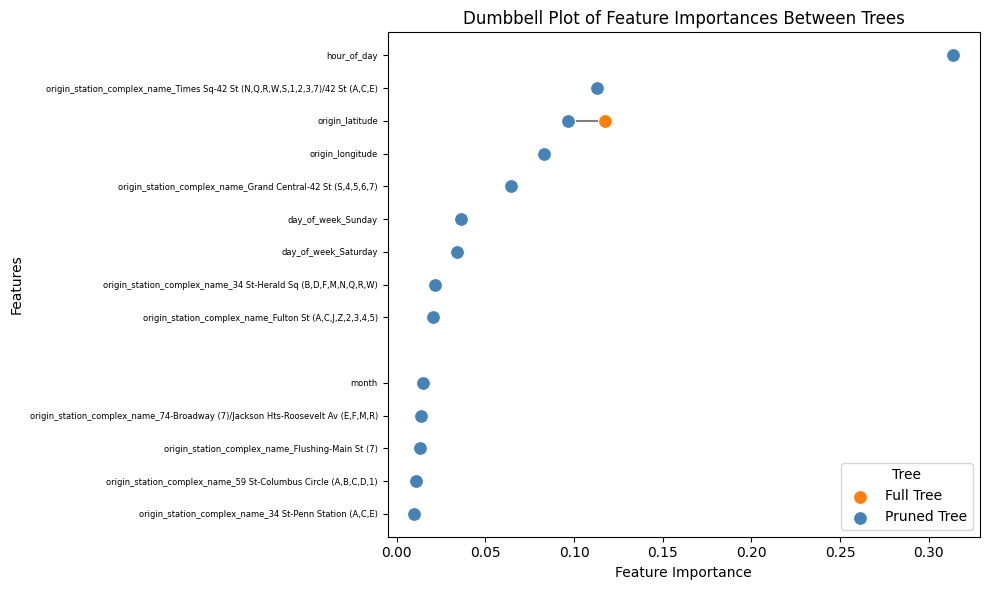

In [36]:
# Point for the full tree
# sns.set_theme(font_scale=1.5)  # Increases all text by 50%
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x = feat_import_df['full'],
    y = feat_import_df.index,
    color = '#FF7F0E',
    s = 100,
    label = 'Full Tree',
    zorder = 2
)

# Points for the pruned tree
sns.scatterplot(
    x = feat_import_df['pruned'],
    y = feat_import_df.index,
    color = 'steelblue',
    s = 100,
    label = 'Pruned Tree',
    zorder = 2
)

# Adding the lines
for i, row in feat_import_df.iterrows():
    plt.plot(
        [row['full'], row['pruned']],
        [i,i],
        color = 'grey',
        zorder = 1
    )

plt.title("Dumbbell Plot of Feature Importances Between Trees")
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.yticks(feat_import_df.index, feat_import_df['feature'], fontsize = 6)
plt.legend(title='Tree', loc='lower right')
plt.tight_layout()

## Decision Tree Without Stations

The impetus for this is that the tree appears to be quite overfit. This could be because of the vast number of stations, where the stations allow for a lot of mini-trees within the larger tree that can super easily target each ridership value. To see if this is needed, I will just be removing the stations from the dataset

In [12]:
from sklearn.preprocessing import OneHotEncoder

url_ts = "https://raw.githubusercontent.com/iansargent/nyc-subway-ridership-ml/main/Data/Clean/origin_ridership_time_series_CLEAN.csv"
origin = pd.read_csv(StringIO(requests.get(url_ts, verify=False).text))
#split into X and Y datasets
num_cols = origin.shape[1]
X = origin.iloc[:,0:num_cols-2]
X = X.drop('origin_station_complex_id', axis=1) #drop complex_id b/c it is the same as complex_name in terms of analysis
X = X.drop('origin_station_complex_name', axis=1) #drop complex_id b/c it is the same as complex_name in terms of analysis

Y = origin.iloc[:,num_cols-1:num_cols]
Y = np.ravel(Y)

#one hot encoding
categorical_columns = X.select_dtypes(include=['object']).columns.tolist()
encoder = OneHotEncoder(sparse_output=False, drop = 'first')
one_hot_encoded = encoder.fit_transform(X[categorical_columns])
one_hot_df = pd.DataFrame(one_hot_encoded, columns=encoder.get_feature_names_out(categorical_columns))
df_encoded = pd.concat([X, one_hot_df], axis=1)
df_encoded = df_encoded.drop(categorical_columns, axis=1)
X = df_encoded

# print(X)

#train test split
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.25, random_state=4)

In [26]:
small_ridership_tree = (
    DecisionTreeRegressor(random_state = 3870)
    .fit(X = X_train, y = y_train)
)
R2_train = small_ridership_tree.score(X_train, y_train)
R2_test = small_ridership_tree.score(X_test, y_test)

# print(f'R-squared for the training set is:{np.sqrt(R2_train): .2f} and the R-squared of the test set is {np.sqrt(R2_test): .2f}')
print(f'R-squared for the training set is: {np.sqrt(R2_train)} and the R-squared of the test set is {np.sqrt(R2_test)}')

R-squared for the training set is: 1.0 and the R-squared of the test set is 0.9911408130727509


In [15]:
from sklearn.model_selection import GridSearchCV

#aiming for a smaller tree
param_grid = {'max_depth':range(1, 30, 1)}
cross_val_tree = DecisionTreeRegressor()
search = GridSearchCV(cross_val_tree, param_grid, cv=5, scoring = 'r2')
grid_search = search.fit(X_train, y_train)

Text(0, 0.5, 'Val Accuracy')

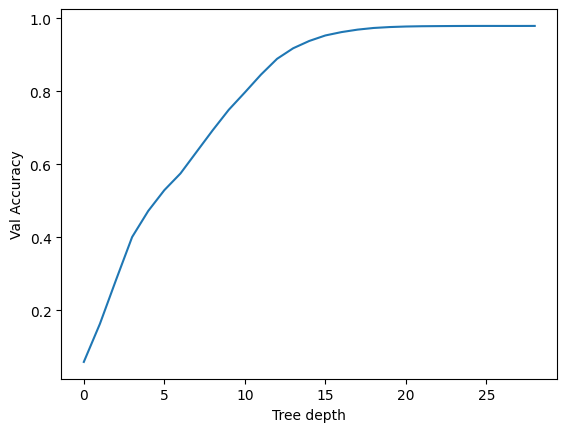

In [16]:
plt.plot(search.cv_results_['mean_test_score'])
plt.xlabel('Tree depth')
plt.ylabel('Val Accuracy')

In [25]:
depth = grid_search.best_params_['max_depth']
print(depth)
small_ridership_tree_pruned = DecisionTreeRegressor(max_depth=depth).fit(X_train, y_train)
R2_train = small_ridership_tree_pruned.score(X_train, y_train)
R2_test = small_ridership_tree_pruned.score(X_test, y_test)

# print(f'R-squared for the training set is:{np.sqrt(R2_train): .2f} and the R-squared of the test set is {np.sqrt(R2_test): .2f}')
print(f'R-squared for the training set is: {np.sqrt(R2_train)} and the R-squared of the test set is {np.sqrt(R2_test)}')

29
R-squared for the training set is:0.9999541808763431 and the R-squared of the test set is 0.9911931629209159


In [18]:
import pickle

with open('small_pruned_tree.pkl', 'wb') as f:
    pickle.dump(small_ridership_tree_pruned, f)

In [22]:
feat_import_pruned = small_ridership_tree_pruned.feature_importances_
feat_import_full = small_ridership_tree.feature_importances_

feat_import_df = pd.DataFrame({
        'feature': X_train.columns,
        'full': feat_import_full,
        'pruned': feat_import_pruned
    }).sort_values(by = 'pruned').reset_index().drop(columns = 'index', axis = 1)

In [23]:
feat_import_df = feat_import_df[feat_import_df['full'] >= .01]
feat_import_df = feat_import_df[feat_import_df['pruned'] >= .01]

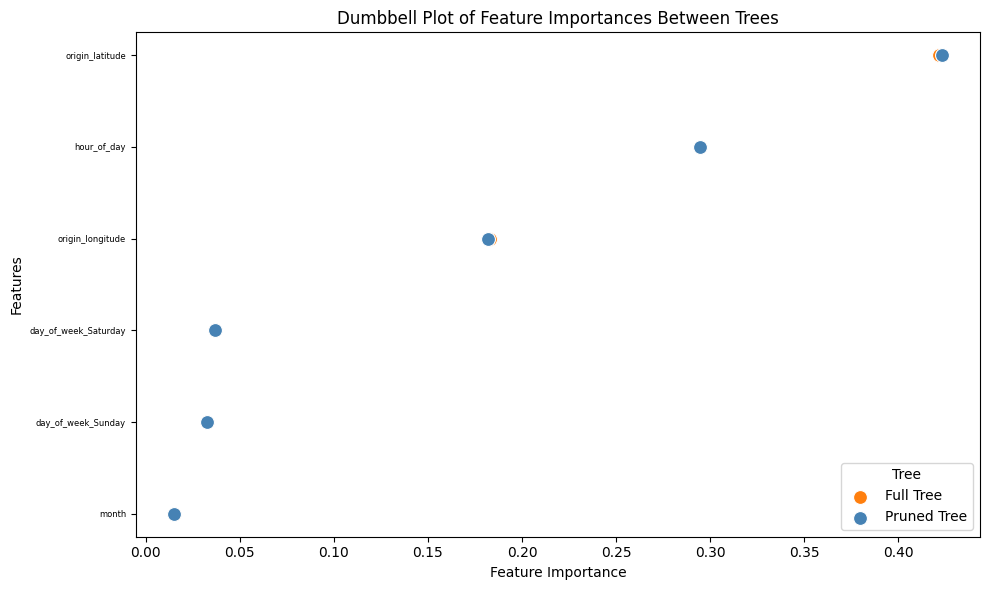

In [24]:
# Point for the full tree
# sns.set_theme(font_scale=1.5)  # Increases all text by 50%
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x = feat_import_df['full'],
    y = feat_import_df.index,
    color = '#FF7F0E',
    s = 100,
    label = 'Full Tree',
    zorder = 2
)

# Points for the pruned tree
sns.scatterplot(
    x = feat_import_df['pruned'],
    y = feat_import_df.index,
    color = 'steelblue',
    s = 100,
    label = 'Pruned Tree',
    zorder = 2
)

# Adding the lines
for i, row in feat_import_df.iterrows():
    plt.plot(
        [row['full'], row['pruned']],
        [i,i],
        color = 'grey',
        zorder = 1
    )

plt.title("Dumbbell Plot of Feature Importances Between Trees")
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.yticks(feat_import_df.index, feat_import_df['feature'], fontsize = 6)
plt.legend(title='Tree', loc='lower right')
plt.tight_layout()

### Interperation

I would go with the smaller tree. it appears a lot of the station differences are covered by longitude and latitude, and other than that they are similar in terms of performance

# Lasso

In [11]:
# standardize
from sklearn.preprocessing import StandardScaler

scalerX = StandardScaler().fit(X_train)
X_train_scaled = scalerX.transform(X_train)
X_test_scaled = scalerX.transform(X_test)



In [55]:
from sklearn.linear_model import Ridge, Lasso, LinearRegression


# Starting the lasso regression engine
lasso_10 = Lasso(alpha = 10)
lasso_10.fit(X_train, y_train)
lasso_coefs10 = lasso_10.coef_

linear_model = LinearRegression().fit(X_train, y_train)
linear_coefs = linear_model.coef_

# Most of the differences are 0's
pd.DataFrame({
    'term' : X_train.columns,
    'OLS'  : linear_coefs,
    'Lasso': lasso_coefs10,
    'estimate_diff': (lasso_coefs10 - linear_coefs)#.round().astype(int)
})#.query('estimate_diff != 0')

,term,OLS,Lasso,estimate_diff
0,month,3.319668,2.426274,-0.893393
1,hour_of_day,13.491434,13.266051,-0.225384
2,origin_latitude,714.939817,0.000000,-714.939817
3,origin_longitude,-3400.145607,-0.000000,3400.145607
4,day_of_week_Monday,-12.521707,-0.000000,12.521707
...,...,...,...,...
428,"origin_station_complex_name_Woodhaven Blvd (J,Z)",-178.970930,-0.000000,178.970930
429,"origin_station_complex_name_Woodhaven Blvd (M,R)",152.531642,0.000000,-152.531642
430,origin_station_complex_name_Woodlawn (4),-318.429534,-0.000000,318.429534
431,origin_station_complex_name_York St (F),-308.023374,0.000000,308.023374


In [56]:
# how many coeffs aren't zero
sum(np.abs(lasso_10.coef_) > 0)

np.int64(5)

In [57]:
# Getting the coefficients of the model for the best choice of lambda
vars_matter_df = pd.DataFrame({
    'feature' : X.columns,
    'estimate': lasso_10.coef_.round(2)
}).query('estimate != 0')
display(vars_matter_df)



,feature,estimate
0,month,2.43
1,hour_of_day,13.27
5,day_of_week_Saturday,-28.85
6,day_of_week_Sunday,-75.07
408,"origin_station_complex_name_Times Sq-42 St (N,...",448.70


,feature,estimate
0,month,3.33
1,hour_of_day,13.49
2,origin_latitude,320.82
3,origin_longitude,-1119.91
4,day_of_week_Monday,-12.57
...,...,...
398,origin_station_complex_name_South Ferry (1)/Wh...,481.38
405,origin_station_complex_name_Sutphin Blvd-Arche...,715.02
408,"origin_station_complex_name_Times Sq-42 St (N,...",4843.87
417,"origin_station_complex_name_W 4 St-Wash Sq (A,...",980.03


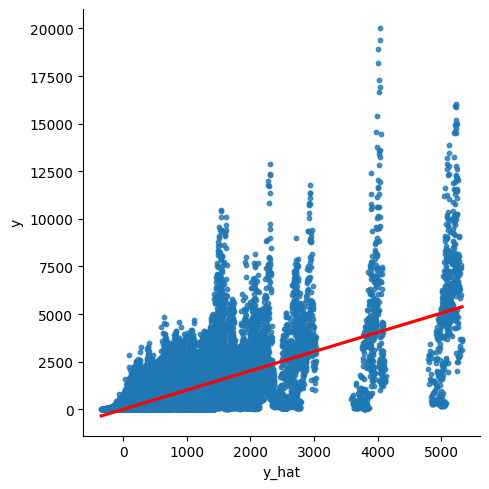

In [58]:
# fit mlr model with significant predictors


best_mlr = (
    LinearRegression()
    .fit(
        X = X_train[vars_matter['feature']],
        y = y_train
    )
)

display(pd.DataFrame({
    'feature' : vars_matter['feature'],
    'estimate': best_mlr.coef_.round(2)
}))

# Creating an R-squared plot:
sns.lmplot(
    data = pd.DataFrame({
        'y': y_test,
        'y_hat': best_mlr.predict(X = X_test[vars_matter['feature']])
    }),
    x = 'y_hat',
    y = 'y',
    line_kws = {'color': 'red'},
    scatter_kws = {'s' : 10}
)

plt.show()

In [59]:
origin[origin['origin_station_complex_name'] != 'Times Sq-42 St (N,Q,R,W,S,1,2,3,7)/42 St (A,C,E)']['sum_estimated_average_ridership'].mean()

np.float64(310.7676970984243)

In [60]:
origin[origin['origin_station_complex_name'] != 'Times Sq-42 St (N,Q,R,W,S,1,2,3,7)/42 St (A,C,E)']['sum_estimated_average_ridership'].mean()

np.float64(310.7676970984243)

In [61]:
best_mlr.score(X_test[vars_matter['feature']], y_test)

0.49154639113820764

### Take 2

In [46]:
# 5-fold cross-validation to choose lambda
from sklearn.linear_model import LassoCV

lasso_cv_model = LassoCV(
   alphas=np.arange(0.01, 10, 0.2), cv=5, max_iter=100000
)

# fit model on train set
lasso_best = lasso_cv_model.fit(X_train_scaled, y_train)

In [47]:
# chosen value of lambda
lasso_best.alpha_

np.float64(0.01)

In [48]:
# Getting the coefficients of the model for the best choice of lambda
vars_matter_df_2 = pd.DataFrame({
    'feature' : X.columns,
    'estimate': lasso_best.coef_.round(2)
}).query('estimate != 0')
display(vars_matter_df_2)

,feature,estimate
0,month,11.45
1,hour_of_day,93.35
3,origin_longitude,-263.75
4,day_of_week_Monday,-4.38
5,day_of_week_Saturday,-38.55
...,...,...
427,"origin_station_complex_name_Winthrop St (2,5)",-16.21
429,"origin_station_complex_name_Woodhaven Blvd (M,R)",16.43
430,origin_station_complex_name_Woodlawn (4),-1.75
431,origin_station_complex_name_York St (F),-14.46


,feature,estimate
0,month,3.32
1,hour_of_day,13.49
3,origin_longitude,-4979.74
4,day_of_week_Monday,-12.52
5,day_of_week_Saturday,-110.28
...,...,...
427,"origin_station_complex_name_Winthrop St (2,5)",-363.72
429,"origin_station_complex_name_Woodhaven Blvd (M,R)",331.62
430,origin_station_complex_name_Woodlawn (4),-45.05
431,origin_station_complex_name_York St (F),-337.25


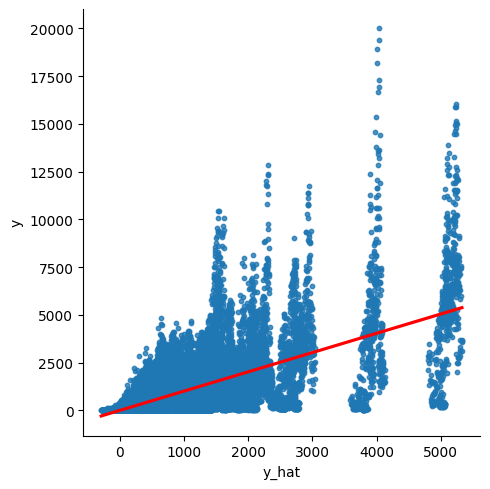

In [50]:
# fit mlr model with significant predictors


best_mlr_2 = (
    LinearRegression()
    .fit(
        X = X_train[vars_matter_df_2['feature']],
        y = y_train
    )
)

display(pd.DataFrame({
    'feature' : vars_matter_df_2['feature'],
    'estimate': best_mlr_2.coef_.round(2)
}))

# Creating an R-squared plot:
sns.lmplot(
    data = pd.DataFrame({
        'y': y_test,
        'y_hat': best_mlr_2.predict(X = X_test[vars_matter_df_2['feature']])
    }),
    x = 'y_hat',
    y = 'y',
    line_kws = {'color': 'red'},
    scatter_kws = {'s' : 10}
)

plt.show()

In [53]:
best_mlr_2.score(X_test[vars_matter_df_2['feature']], y_test)

0.5084111434241331